# Non Regulariation Chapter 7 Workshop 9

## Load data

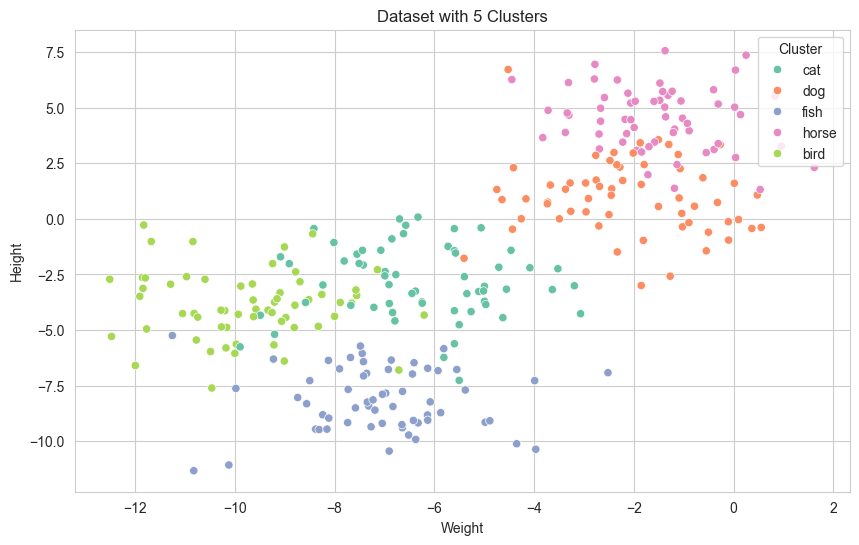

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=5, n_features=2, cluster_std=1.5, random_state=1)
X_df = pd.DataFrame(X, columns=['weight', 'height'])

y_df = pd.DataFrame(y, columns=['class'])
df = pd.concat([X_df, y_df], axis=1)

target_map = {
    0: 'horse',
    1: 'bird',
    2: 'fish',
    3: 'cat',
    4: 'dog'
}

# Map the labels to animal names
df['class'] = df['class'].map(target_map)

# Plot the dataset
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='weight', y='height', hue='class', palette='Set2')
plt.title('Dataset with 5 Clusters')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.legend(title='Cluster', loc='upper right')
plt.show()

class_names, y = np.unique(df['class'], return_inverse=True)

### Debug

In [6]:
print(class_names[:5])
print(y[:5])
print(X[:5])

print('y type:', type(y))
print('class_names type:', type(class_names))
print('X type:', type(X))


['bird' 'cat' 'dog' 'fish' 'horse']
[1 2 3 4 0]
[[ -3.06805367  -4.26708645]
 [ -4.16286974   0.89898641]
 [ -7.04485317  -9.1952685 ]
 [ -2.06139203   5.20202307]
 [-11.6763856   -1.01923019]]
y type: <class 'numpy.ndarray'>
class_names type: <class 'numpy.ndarray'>
X type: <class 'numpy.ndarray'>


In [3]:
print(X_df.shape)

(300, 2)


## Prepare data

### Prepare feature X 

In [4]:
X = df.drop(columns=['class'])
X.sample(5, random_state=1)

,weight,height
189,-3.335525,4.758113
123,-4.707304,-2.176013
185,-5.263202,-4.172373
213,-0.322491,0.735041
106,-6.921745,-6.771053


### Standard Scale

In [5]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_sc = sc.fit_transform(X)

### Split Train and Test Data

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_sc, y, 
                                                    test_size=0.25, 
                                                    random_state=1)

In [25]:
print(X_train.shape)

(225, 2)


## Create Model

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Create model
model = Sequential()
# Add hidden layers
model.add(Dense(256, activation='relu', input_shape=(X_df.shape[1],)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

# Add output layer
model.add(Dense(5, activation='softmax')) # Use softmax for multi-class classification

d:\Project\Learning\Environment_Project\tensorflow\evn1\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile model

In [15]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

## Model Traning

In [17]:
history = model.fit(X_train, y_train, 
                    epochs=1000, 
                    batch_size=256, 
                    validation_data=(X_test, y_test), 
                    verbose=1)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 750ms/step - accuracy: 0.2000 - loss: 1.5975 - val_accuracy: 0.4800 - val_loss: 1.5459
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4178 - loss: 1.5549 - val_accuracy: 0.5733 - val_loss: 1.5053
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5378 - loss: 1.5187 - val_accuracy: 0.5733 - val_loss: 1.4674
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5467 - loss: 1.4851 - val_accuracy: 0.5733 - val_loss: 1.4305
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5422 - loss: 1.4521 - val_accuracy: 0.5733 - val_loss: 1.3953
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5422 - loss: 1.4202 - val_accuracy: 0.5733 - val_loss: 1.3612
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5422 - loss: 1.3890 - val_accuracy: 0.5733 - val_loss: 1.3268
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5422 - loss: 1.3579 - val_accuracy: 0.5733 - 

## Plot Loss and Accuracy 

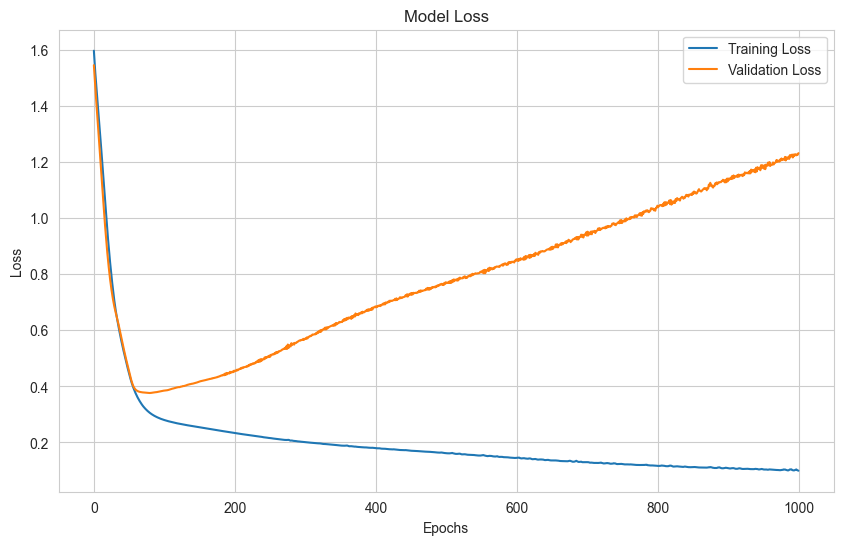

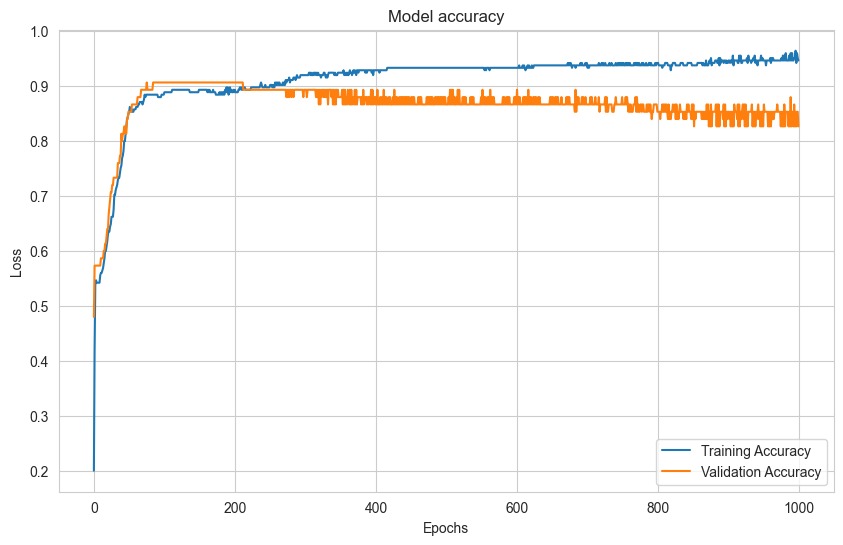

In [21]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Create one-hot function

In [23]:
class Onehot2int(object):
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        y_pred = self.model.predict(X)
        # Convert the predicted probabilities to one-hot encoding
        return np.argmax(y_pred, axis=1)
# Create an instance of the Onehot2int class
model_no_ohe = Onehot2int(model)

## Model Decision Boudary 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 5s 530us/step


d:\Project\Learning\Environment_Project\tensorflow\evn1\Lib\site-packages\mlxtend\plotting\decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


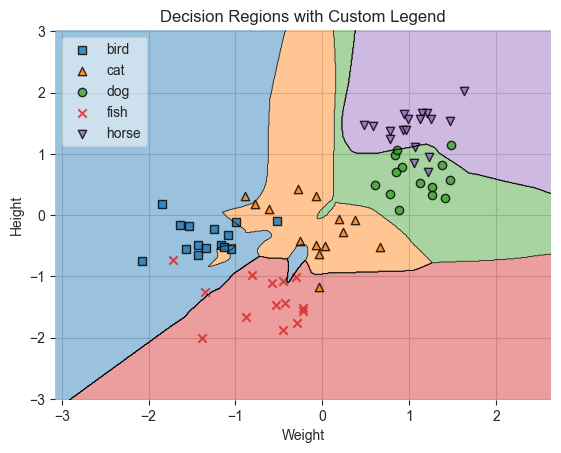

In [24]:
from mlxtend.plotting import plot_decision_regions
ax = plot_decision_regions(X_test, y_test, clf=model_no_ohe,)

handles, labels = ax.get_legend_handles_labels()
# Create a custom legend
ax.legend(handles, class_names, framealpha=0.5)
plt.title('Decision Regions with Custom Legend')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

# Regularization L1 Chapter 7 Workshop 10

## Create model

non reguliazion : Loss = Error(y_pred,y_true)
l1 : Loss = Error(y_pred,y_true) + a * |w|
l2 : Loss = Error(y_pred,y_true) + a * (w**2)

constant is a that must be specified 

In [26]:
from tensorflow.keras.regularizers import l1, l2, l1_l2

# Create model
model = Sequential()
# Add hidden layers
model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l1(0.001)))
model.add(Dense(128, activation='relu', kernel_regularizer=l1(0.001)))
model.add(Dense(64, activation='relu', kernel_regularizer=l1(0.001)))

# Add output layer
model.add(Dense(5, activation='softmax')) # Use softmax for multi-class classification

d:\Project\Learning\Environment_Project\tensorflow\evn1\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile model

In [27]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


## Train model

In [28]:
history = model.fit(X_train, y_train, 
                    epochs=1000, 
                    batch_size=256, 
                    validation_data=(X_test, y_test), 
                    verbose=1)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step - accuracy: 0.0622 - loss: 4.4498 - val_accuracy: 0.3600 - val_loss: 4.3648
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.2533 - loss: 4.3710 - val_accuracy: 0.5733 - val_loss: 4.2893
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4844 - loss: 4.2989 - val_accuracy: 0.6133 - val_loss: 4.2190
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5822 - loss: 4.2318 - val_accuracy: 0.6000 - val_loss: 4.1547
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5822 - loss: 4.1701 - val_accuracy: 0.5867 - val_loss: 4.0930
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5778 - loss: 4.1114 - val_accuracy: 0.5867 - val_loss: 4.0319
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5778 - loss: 4.0531 - val_accuracy: 0.5867 - val_loss: 3.9717
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5822 - loss: 3.9956 - val_accuracy: 0.5867 - 

## Evaluate model

In [33]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', round(score[0],3))
print('Test accuracy:', round(score[1],3))

Test loss: 0.601
Test accuracy: 0.893


## Plot Loss and Accuracy 

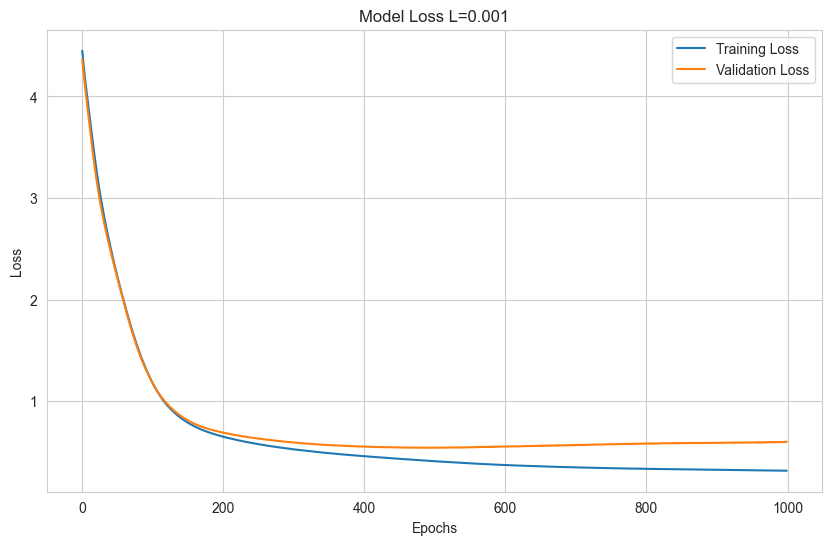

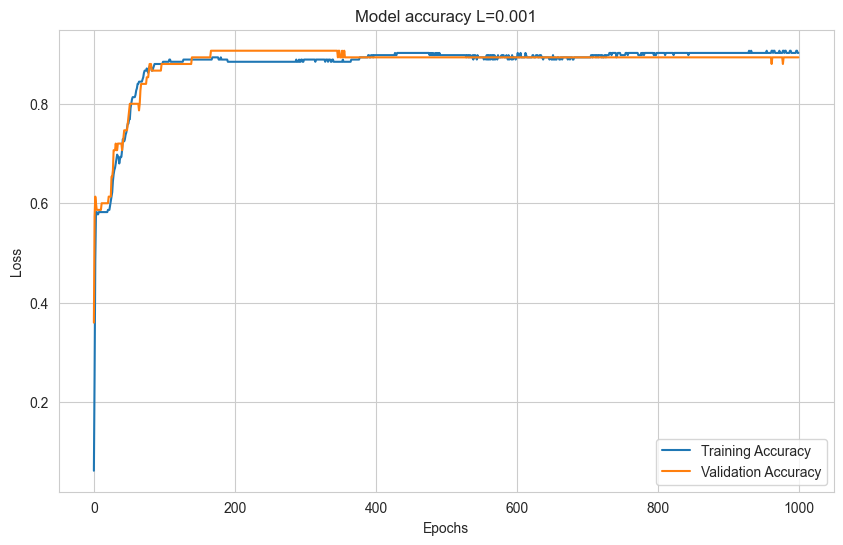

In [35]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss L=0.001')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model accuracy L=0.001')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Model Decision Boudary 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 5s 558us/step


d:\Project\Learning\Environment_Project\tensorflow\evn1\Lib\site-packages\mlxtend\plotting\decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


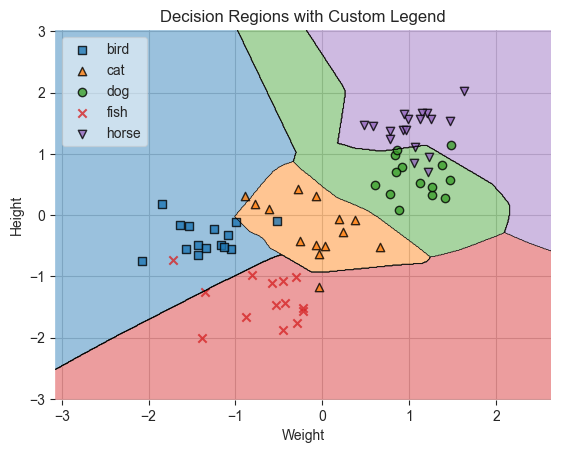

In [36]:
from mlxtend.plotting import plot_decision_regions

model_no_ohe = Onehot2int(model)

ax = plot_decision_regions(X_test, y_test, clf=model_no_ohe,)

handles, labels = ax.get_legend_handles_labels()
# Create a custom legend
ax.legend(handles, class_names, framealpha=0.5)
plt.title('Decision Regions with Custom Legend')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()